# 🧠 Modélisation Prédictive des 9 Cibles Clés de la Simulation (Couches 1 & 2)

Ce notebook implémente l'entraînement des modèles de Machine Learning pour prédire les 9 variables critiques régissant notre univers de simulation (MiroFish).

Chaque modèle est entraîné sur un sous-ensemble de variables **spécifiquement sélectionnées** pour éviter :
- Le **bruit** (variables sans lien physique avec la cible)
- La **fuite de données** (features utilisées directement dans le calcul déterministe de la cible)

### 🎯 Les 9 Variables Cibles
1. **Rendement Agricole (`target_yield`)** — Prédit à partir du climat, intrants, sols, terres + **type de culture** (Target Encoding)
2. **Stress Hydrique (`target_water_stress`)** — Prédit à partir du climat, hydrologie, pression anthropique
3. **Dynamique des Biomes (`target_npp`)** — Prédit **SANS** `temp_mean`/`precip_mean` (ils sont dans la formule Miami Model)
4. **Risque d'Inondation (`target_flood_risk`)** — Prédit **SANS** `elevation`/`dist_to_freshwater_km` (règle booléenne)
5. **Dégradation du Sol (`target_soil_degradation`)** — Prédit à partir de la texture du sol et intrants
6. **Densité de la Faune (`target_fauna_density`)** — Prédit **SANS** `npp_g_m2_yr` (fauna = 0.05 × NPP)
7. **Prolifération Parasitaire (`target_parasite_vsi`)** — Prédit **SANS** `temp_mean`/`precip_mean` (formule VSI)
8. **Anomalie Thermique Locale (`target_thermal_anomaly`)** — Prédit à partir du rayonnement et sources d'énergie
9. **Probabilité d'Érosion (`target_erosion_prob`)** — Prédit **SANS** `dist_to_coast`/`tide_amplitude`/`dist_to_river` (formule exacte)

---

In [1]:
# ── IMPORTATIONS & CONFIGURATION ──────────────────────────────────────────
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, f1_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)
print("✅ Importations terminées avec succès.")

✅ Importations terminées avec succès.


## 📦 1. Chargement du Dataset et Préparation

Nous chargeons le fichier consolidé et encodé `dataset_final_modelisation.csv`.
Pour le **rendement agricole**, nous ajoutons un **Target Encoding** de la colonne `Produit` (type de culture) et `ISO` (pays), calculé sur le train set uniquement pour éviter la fuite de données.

In [2]:
# ── CHARGEMENT & PRÉPARATION ──────────────────────────────────────────────
dataset_path = "data/cleaned/dataset_final_modelisation.csv"
df = pd.read_csv(dataset_path)
print(f"Shape du dataset chargé : {df.shape}")

# Suppression des lignes sans rendement (base de notre dataset)
# + sans ISO : 'ISO' sert de groupe pour le split par pays (GroupShuffleSplit
#   refuse un groupe NaN), et c'est la clé de jointure entre couches.
df = df.dropna(subset=['Rendement_kgha', 'ISO']).copy()
print(f"Lignes après filtrage (rendement + ISO) : {len(df):,} | pays : {df['ISO'].nunique()}")

# ── TARGET ENCODING de Produit et ISO (calculé sur Train UNIQUEMENT) ──────
# Split temporel d'abord
train_mask_global = df['Annee'] <= 2013

# Target Encoding Produit : moyenne du log1p_rendement par culture sur le train
produit_means = df.loc[train_mask_global].groupby('Produit')['log1p_Rendement'].mean()
global_mean = df.loc[train_mask_global, 'log1p_Rendement'].mean()
df['Produit_TargetEnc'] = df['Produit'].map(produit_means).fillna(global_mean)

# Target Encoding ISO : moyenne du log1p_rendement par pays sur le train
iso_means = df.loc[train_mask_global].groupby('ISO')['log1p_Rendement'].mean()
df['ISO_TargetEnc'] = df['ISO'].map(iso_means).fillna(global_mean)

print(f"\n✅ Target Encoding appliqué :")
print(f"   - Produit : {len(produit_means)} catégories encodées")
print(f"   - ISO     : {len(iso_means)} pays encodés")
print(f"   - Moyenne globale (fallback) : {global_mean:.4f}")

Shape du dataset chargé : (153374, 180)
Lignes après filtrage (rendement + ISO) : 152,898 | pays : 186



✅ Target Encoding appliqué :
   - Produit : 168 catégories encodées
   - ISO     : 186 pays encodés
   - Moyenne globale (fallback) : 8.4156


## 🛠️ 2. Définition des Features Spécifiques par Cible

**Règle anti-fuite** : pour chaque cible, on **exclut** les variables qui apparaissent directement dans la formule déterministe de la cible.

| Cible | Variables exclues | Raison |
|---|---|---|
| NPP | `temp_mean`, `precip_mean` | Formule Miami Model = `min(f(T), g(P))` |
| Fauna | `npp_g_m2_yr` | `fauna = 0.05 × NPP` |
| VSI | `temp_mean`, `precip_mean` | `VSI = 10 × exp(…T…) × (1-exp(…P…))` |
| Érosion | `dist_to_coast`, `tide_amplitude`, `dist_to_river` | Formule exponentielle exacte |
| Flood | `elevation`, `dist_to_freshwater` | Règle booléenne `(elev≤50) & (dist≤5)` |

In [3]:
# ── CONFIGURATION DES FEATURES PAR CIBLE (CORRIGÉ ANTI-FUITE) ───────────

# 1. Rendement Agricole : Climat + Intrants + Sols + Terres + IDENTITÉ CULTURE/PAYS
features_yield = [
    'Annee',
    'Produit_TargetEnc', 'ISO_TargetEnc',  # <-- NOUVEAU : identité culture + pays
    'Engrais_kgha', 'Pesticides_kgha', 'Bilan_sols_kgha',
    'log_Engrais_kgha', 'log_Pesticides_kgha',
    'Temperature_C', 'Temperature_C_sq',
    'Precipitations_mm', 'Precipitations_mm_sq',
    'Engrais_Temp_interaction',
    'Superficie_pays_ha', 'Superficie_terres_ha', 'Terres_agricoles_ha',
    'Terres_culture_ha', 'Terres_arables_ha', 'Irrigation_equipee_ha',
    'Irrigation_reelle_ha', 'Bio_ha',
    'Part_terres_agricoles', 'Part_terres_arables', 'Part_irriguee', 'Part_bio'
]

# 2. Stress Hydrique : Climat + Hydrologie + Pression anthropique (PAS de leakage ici)
features_water_stress = [
    'temp_mean', 'precip_mean', 'precip_seasonality',
    'dist_to_river_km', 'dist_to_lake_km', 'dist_to_coast_km', 'dist_to_freshwater_km', 'groundwater_depth_m',
    'GDP_pc', 'HDI', 'Superficie_pays_ha', 'Terres_agricoles_ha'
]

# 3. NPP : SANS temp_mean/precip_mean (formule Miami: NPP = min(f(T), g(P)))
#    On utilise des proxies corrélés mais pas dans la formule
features_npp = [
    'latitude',  # proxy de température
    'elevation',  # affecte température en altitude
    'solar_radiation_mean',  # énergie lumineuse, corrélé au climat
    'vapor_pressure_mean',  # humidité atmosphérique
    'precip_seasonality',  # régularité des pluies (pas la quantité)
    'wind_speed_mean',  # stress éolien
    'temp_max', 'temp_min',  # extremes (pas temp_mean qui est dans la formule)
    'dist_to_coast_km'  # effet maritime sur le climat
]

# 4. Flood Risk : SANS elevation et dist_to_freshwater (règle : elev<=50 & dist<=5)
features_flood_risk = [
    'slope_pct', 'roughness_m',  # topographie indirecte
    'dist_to_river_km', 'dist_to_lake_km', 'dist_to_coast_km',
    'groundwater_depth_m',
    'precip_mean', 'precip_seasonality',
    'clay_pct', 'sand_pct'  # perméabilité du sol
]

# 5. Dégradation du Sol : Texture + Intrants + Intensité (PAS de leakage ici)
features_soil_degradation = [
    'clay_pct', 'silt_pct', 'sand_pct', 'soil_pH', 'organic_carbon_pct',
    'Engrais_kgha', 'Pesticides_kgha', 'log_Engrais_kgha',
    'Part_terres_agricoles', 'Part_terres_arables', 'Part_irriguee'
]

# 6. Fauna Density : SANS npp_g_m2_yr (fauna = 0.05 * NPP, linéaire direct)
#    On utilise les inputs qui déterminent l'habitat
features_fauna_density = [
    'temp_mean', 'precip_mean',  # déterminent la végétation
    'elevation', 'solar_radiation_mean',
    'estimated_wood_density_g_cm3',  # densité forestière
    'vapor_pressure_mean', 'precip_seasonality',
    'dist_to_freshwater_km'  # accès eau
]

# 7. VSI : SANS temp_mean/precip_mean (VSI = 10 * exp(-((T-26)²)/50) * (1-exp(-P/800)))
features_parasite_vsi = [
    'latitude',  # proxy de température zonale
    'elevation',  # température d'altitude
    'vapor_pressure_mean',  # humidité
    'solar_radiation_mean',
    'temp_max', 'temp_min',  # extremes (pas temp_mean)
    'precip_seasonality',  # régularité des pluies
    'wind_speed_mean',
    'dist_to_freshwater_km'  # zones humides
]

# 8. Anomalie Thermique : Rayonnement + Proximite industrielle (PAS de leakage)
energy_dummies = [col for col in df.columns if col.startswith('closest_energy_type_')]
features_thermal_anomaly = [
    'temp_mean', 'temp_max', 'temp_min', 'solar_radiation_mean',
    'dist_to_energy_source_km'
] + energy_dummies

# 9. Érosion : SANS dist_to_coast/tide_amplitude/dist_to_river (formule exacte)
features_erosion_prob = [
    'elevation', 'slope_pct', 'roughness_m',  # topographie
    'dist_to_lake_km', 'dist_to_freshwater_km',  # proxy humidité
    'precip_mean', 'precip_seasonality',  # climat
    'clay_pct', 'sand_pct',  # friabilité du sol
    'wind_speed_mean'  # érosion éolienne
]

# Dictionnaire de mapping
target_features_map = {
    'target_yield': features_yield,
    'target_water_stress': features_water_stress,
    'target_npp': features_npp,
    'target_flood_risk': features_flood_risk,
    'target_soil_degradation': features_soil_degradation,
    'target_fauna_density': features_fauna_density,
    'target_parasite_vsi': features_parasite_vsi,
    'target_thermal_anomaly': features_thermal_anomaly,
    'target_erosion_prob': features_erosion_prob
}

print("✅ Configuration des features par cible complétée (anti-fuite activé).")
for name, feats in target_features_map.items():
    valid = [c for c in feats if c in df.columns]
    print(f"   {name}: {len(valid)} features")

✅ Configuration des features par cible complétée (anti-fuite activé).
   target_yield: 25 features
   target_water_stress: 12 features
   target_npp: 9 features
   target_flood_risk: 10 features
   target_soil_degradation: 11 features
   target_fauna_density: 8 features
   target_parasite_vsi: 9 features
   target_thermal_anomaly: 15 features
   target_erosion_prob: 10 features


## 🤖 3. Entraînement de la Boucle Multi-Cible

Pour chacune des 9 cibles, nous :
1. Filtrons les valeurs manquantes
2. **Découpons par PAYS (`GroupShuffleSplit` sur `ISO`)** — les pays du test ne sont **jamais vus** à l'entraînement
3. Entraînons Ridge, Random Forest et XGBoost
4. Sélectionnons et sauvegardons le meilleur modèle

> ⚠️ **Pourquoi un split par pays et non temporel ?**
> Les cibles physiques (`npp`, `fauna`, `vsi`, `erosion`, `flood`) sont des fonctions
> **déterministes** de features géographiques **statiques** (calculées une seule fois
> par pays dans `build_dataset.py`). Elles sont donc **constantes dans le temps pour un
> pays donné**. Avec un split temporel (≤2013 / >2013), **les mêmes pays sont présents
> en train ET en test** : un modèle à base d'arbres mémorise la valeur de chaque pays
> (fingerprint via lat/elevation/temp_max…) → **R² = 1.0 illusoire** (le « problème R² »).
> Le split par pays force le modèle à **généraliser à des pays inconnus** : le R² obtenu
> reflète alors la **vraie** capacité prédictive.
>
> Pour `target_yield`, les encodages `Produit_TargetEnc` / `ISO_TargetEnc` sont
> **recalculés sur le fold d'entraînement uniquement** (un pays de test inconnu reçoit
> la moyenne globale), afin de ne pas réintroduire de fuite.

In [4]:
# ── ENTRAÎNEMENT DES PIPELINES PRÉDICTIVES (v3 – SPLIT PAR PAYS, anti-fuite réelle) ──
targets_info = {
    'target_yield': {'type': 'regression', 'name': 'Rendement Agricole'},
    'target_water_stress': {'type': 'regression', 'name': 'Stress Hydrique'},
    'target_npp': {'type': 'regression', 'name': 'Dynamique des Biomes (NPP)'},
    'target_flood_risk': {'type': 'classification', 'name': "Risque d'Inondation"},
    'target_soil_degradation': {'type': 'regression', 'name': 'Dégradation du Sol'},
    'target_fauna_density': {'type': 'regression', 'name': 'Densité de la Faune'},
    'target_parasite_vsi': {'type': 'regression', 'name': 'Prolifération Parasitaire (VSI)'},
    'target_thermal_anomaly': {'type': 'regression', 'name': 'Anomalie Thermique Locale'},
    'target_erosion_prob': {'type': 'regression', 'name': "Probabilité d'Érosion"}
}

best_models_summary = []
target_test_idx = {}  # mémorise les lignes de test (pays inconnus) pour les diagnostics honnêtes
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

for col_name, info in targets_info.items():
    print(f"\n{'='*70}")
    print(f"🎯 Cible : {info['name']} ({col_name})")
    print(f"{'='*70}")
    
    # 1. Sélection des features
    current_features = target_features_map[col_name]
    
    # 2. Filtrage des NaNs
    df_target = df.dropna(subset=[col_name]).copy()
    if len(df_target) < 100:
        print(f"❌ Données insuffisantes ({len(df_target)} lignes). Pass.")
        continue
        
    # 3. SPLIT PAR PAYS (ISO) : les pays de test ne sont jamais vus à l'entraînement.
    #    (Le split temporel ne protège pas : cibles quasi-constantes par pays -> fuite.)
    tr_idx, te_idx = next(splitter.split(df_target, groups=df_target['ISO']))
    df_tr = df_target.iloc[tr_idx].copy()
    df_te = df_target.iloc[te_idx].copy()
    target_test_idx[col_name] = df_te.index
    
    # 3b. Rendement : recalcul du Target Encoding sur le TRAIN uniquement (anti-fuite)
    if col_name == 'target_yield':
        gmean = df_tr['log1p_Rendement'].mean()
        for src, dst in [('Produit', 'Produit_TargetEnc'), ('ISO', 'ISO_TargetEnc')]:
            means = df_tr.groupby(src)['log1p_Rendement'].mean()
            df_tr[dst] = df_tr[src].map(means).fillna(gmean)
            df_te[dst] = df_te[src].map(means).fillna(gmean)  # pays inconnu -> moyenne globale
    
    # Vérifier les colonnes existantes
    valid_features = [c for c in current_features if c in df_tr.columns]
    
    X_train_raw = df_tr[valid_features]
    y_train = df_tr[col_name]
    X_test_raw = df_te[valid_features]
    y_test = df_te[col_name]
    
    print(f"   Features ({len(valid_features)}) : {valid_features[:10]}...")
    print(f"   Pays train : {df_tr['ISO'].nunique()} | Pays test : {df_te['ISO'].nunique()} (disjoints)")
    print(f"   Train : {X_train_raw.shape[0]:,} | Test : {X_test_raw.shape[0]:,}")
    
    # Pipeline de prétraitement
    preprocessor = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    best_score = -float('inf')
    best_model_name = None
    best_pipeline = None
    
    if info['type'] == 'regression':
        metric_name = 'R2'
        models = {
            'Ridge': Ridge(alpha=1.0),
            'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1),
            'XGBoost': XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
        }
        
        for model_name, model in models.items():
            pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
            pipeline.fit(X_train_raw, y_train)
            y_pred = pipeline.predict(X_test_raw)
            score = r2_score(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            print(f"   [{model_name}] R² = {score:.4f} | MAE = {mae:.4f}")
            
            if score > best_score:
                best_score = score
                best_model_name = model_name
                best_pipeline = pipeline
                
    else:  # classification
        metric_name = 'F1'
        models = {
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1),
            'XGBoost': XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='logloss')
        }
        
        for model_name, model in models.items():
            pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
            pipeline.fit(X_train_raw, y_train)
            y_pred = pipeline.predict(X_test_raw)
            score = f1_score(y_test, y_pred, average='weighted')
            acc = accuracy_score(y_test, y_pred)
            print(f"   [{model_name}] F1 = {score:.4f} | Acc = {acc:.4f}")
            
            if score > best_score:
                best_score = score
                best_model_name = model_name
                best_pipeline = pipeline
                
    # Sauvegarde
    model_filename = f"models/best_{col_name}.joblib"
    joblib.dump(best_pipeline, model_filename)
    print(f"🏆 Meilleur : {best_model_name} ({metric_name} = {best_score:.4f})")
    
    # Alerte si le score reste suspect malgré le split par pays
    if info['type'] == 'regression' and best_score > 0.99:
        print(f"⚠️  ATTENTION : R² = {best_score:.4f} reste très élevé — cible probablement "
              f"déterministe/analytique (à calculer directement plutôt qu'à prédire).")
    
    best_models_summary.append({
        'Cible': info['name'],
        'Nom Technique': col_name,
        'Type': info['type'],
        'Meilleur Modèle': best_model_name,
        'Métrique': metric_name,
        'Score': round(best_score, 4)
    })


🎯 Cible : Rendement Agricole (target_yield)


   Features (25) : ['Annee', 'Produit_TargetEnc', 'ISO_TargetEnc', 'Engrais_kgha', 'Pesticides_kgha', 'Bilan_sols_kgha', 'log_Engrais_kgha', 'log_Pesticides_kgha', 'Temperature_C', 'Temperature_C_sq']...
   Pays train : 139 | Pays test : 47 (disjoints)
   Train : 112,006 | Test : 40,892


   [Ridge] R² = 0.6825 | MAE = 0.6074


   [Random Forest] R² = 0.6660 | MAE = 0.6146


   [XGBoost] R² = 0.6910 | MAE = 0.5901
🏆 Meilleur : XGBoost (R2 = 0.6910)

🎯 Cible : Stress Hydrique (target_water_stress)


...

   [Random Forest] R² = 0.3276 | MAE = 1.5350


   [XGBoost] R² = -0.0768 | MAE = 1.7742
🏆 Meilleur : Random Forest (R2 = 0.3276)

🎯 Cible : Probabilité d'Érosion (target_erosion_prob)


   Features (10) : ['elevation', 'slope_pct', 'roughness_m', 'dist_to_lake_km', 'dist_to_freshwater_km', 'precip_mean', 'precip_seasonality', 'clay_pct', 'sand_pct', 'wind_speed_mean']...
   Pays train : 139 | Pays test : 47 (disjoints)
   Train : 112,006 | Test : 40,892
   [Ridge] R² = -5895.1325 | MAE = 0.3393


   [Random Forest] R² = -16644.5549 | MAE = 0.1459


   [XGBoost] R² = -8335.6909 | MAE = 0.1384
🏆 Meilleur : Ridge (R2 = -5895.1325)


## 📊 4. Tableau Synthétique des Performances

Récapitulatif des scores obtenus sur les données de test (après 2013).
Les colonnes `Métrique` et `Score` sont unifiées (R² pour la régression, F1 pour la classification).

In [5]:
# ── TABLEAU DE PERFORMANCES UNIFIÉ ─────────────────────────────────────
df_summary = pd.DataFrame(best_models_summary)
from IPython.display import display

# Ajouter un code couleur
def color_score(val):
    if isinstance(val, float):
        if val >= 0.8: return 'background-color: #c6efce' # Vert
        elif val >= 0.5: return 'background-color: #ffeb9c' # Jaune
        else: return 'background-color: #ffc7ce' # Rouge
    return ''

styled = df_summary.style.map(color_score, subset=['Score']).format({'Score': '{:.4f}'}).hide(axis='index')
display(styled)

# Stats rapides
reg_scores = df_summary[df_summary['Type']=='regression']['Score']
print(f"\n📊 Régression : R² moyen = {reg_scores.mean():.4f} | Min = {reg_scores.min():.4f} | Max = {reg_scores.max():.4f}")
print(f"⚠️  Cibles encore à R² > 0.99 (= déterministes, à calculer plutôt qu'à prédire) : {(reg_scores > 0.99).sum()}")

Cible,Nom Technique,Type,Meilleur Modèle,Métrique,Score
Rendement Agricole,target_yield,regression,XGBoost,R2,0.6910
Stress Hydrique,target_water_stress,regression,Ridge,R2,-0.0943
Dynamique des Biomes (NPP),target_npp,regression,XGBoost,R2,0.7936
Risque d'Inondation,target_flood_risk,classification,Random Forest,F1,1.0000
Dégradation du Sol,target_soil_degradation,regression,Ridge,R2,0.5342
Densité de la Faune,target_fauna_density,regression,Random Forest,R2,0.9896
Prolifération Parasitaire (VSI),target_parasite_vsi,regression,XGBoost,R2,0.9528
Anomalie Thermique Locale,target_thermal_anomaly,regression,Random Forest,R2,0.3276
Probabilité d'Érosion,target_erosion_prob,regression,Ridge,R2,-5895.1325



📊 Régression : R² moyen = -736.3673 | Min = -5895.1325 | Max = 0.9896
⚠️  Cibles encore à R² > 0.99 (= déterministes, à calculer plutôt qu'à prédire) : 0


## 📈 5. Importance des Features pour le Rendement Agricole

Visualisons l'importance des variables pour notre modèle de rendement (`target_yield`), incluant désormais le **type de culture** (Target Encoding) et l'identité **pays**.

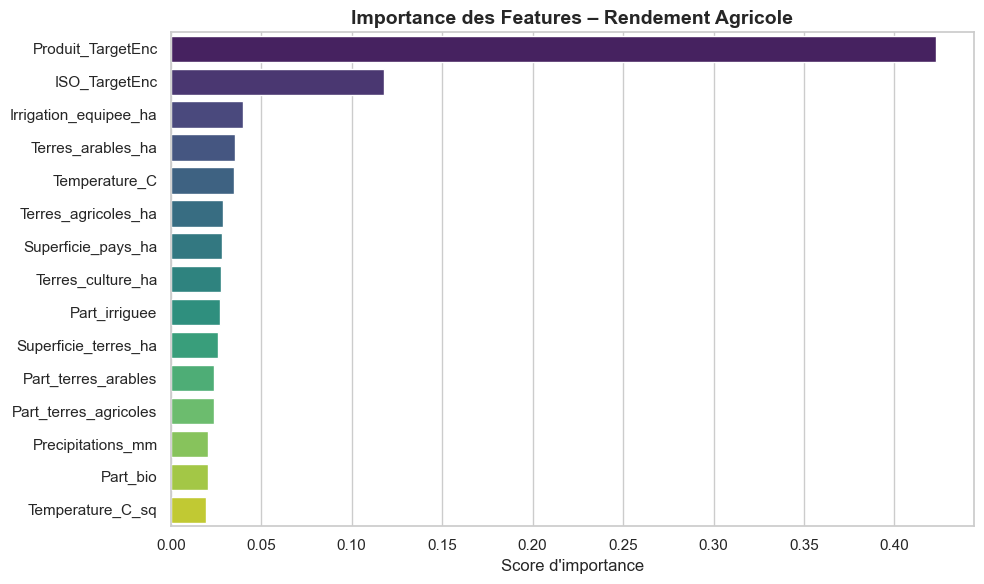

✅ Figure sauvegardée dans reports/yield_feature_importance.png


In [6]:
# ── IMPORTANCE DES FEATURES – RENDEMENT AGRICOLE ───────────────────────
yield_pipe = joblib.load("models/best_target_yield.joblib")
yield_model = yield_pipe.named_steps['model']
yield_features = [c for c in target_features_map['target_yield'] if c in df.columns]

if hasattr(yield_model, 'feature_importances_'):
    importances = yield_model.feature_importances_
    title = "Importance des Features – Rendement Agricole"
else:
    importances = np.abs(yield_model.coef_)
    title = "Coefficients Absolus – Rendement Agricole (Ridge)"
    
indices = np.argsort(importances)[::-1][:15]
top_features = [yield_features[i] for i in indices]
top_importances = importances[indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances, y=top_features, hue=top_features, palette="viridis", legend=False)
plt.title(title, fontsize=14, weight='bold')
plt.xlabel("Score d'importance")
plt.tight_layout()
plt.savefig('reports/yield_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée dans reports/yield_feature_importance.png")

## 🔍 6. Diagnostic Visuel : Prédictions vs Réalité

Scatter plots des 3 cibles les plus critiques pour vérifier la qualité des prédictions.

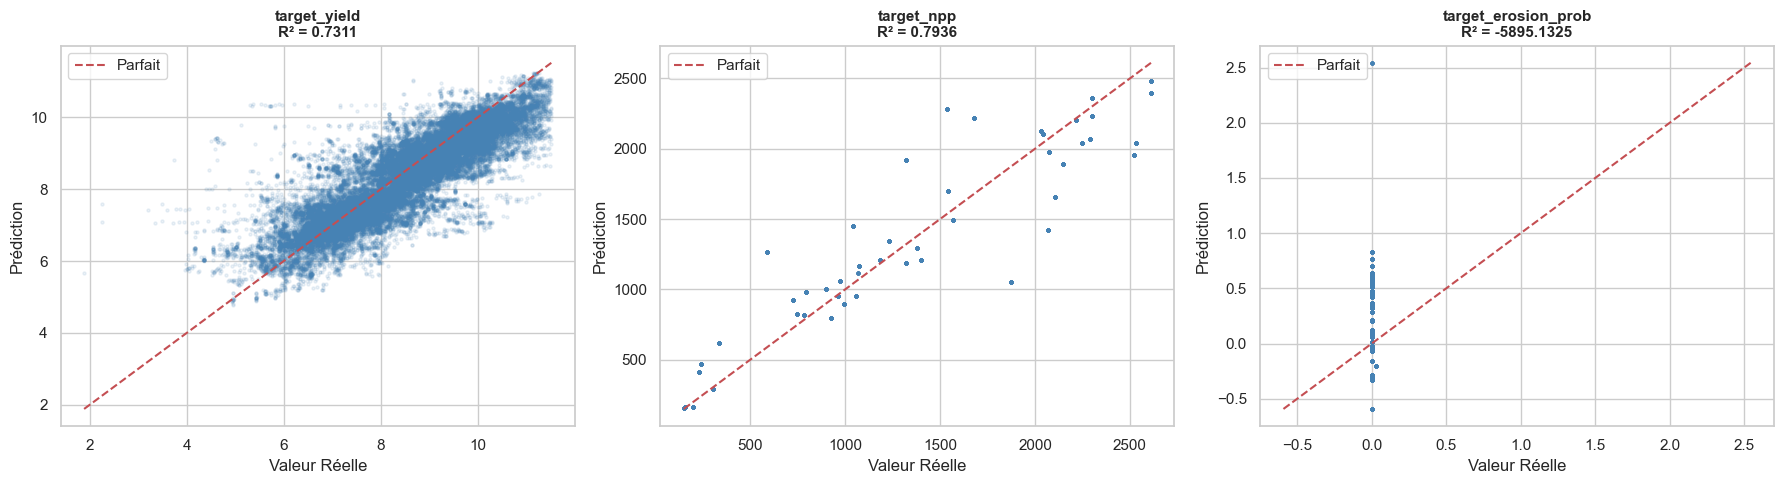

✅ Figures de diagnostic sauvegardées.


In [7]:
# ── DIAGNOSTIC VISUEL : PREDICTIONS VS REALITE (sur pays de test inconnus) ────
diagnostic_targets = ['target_yield', 'target_npp', 'target_erosion_prob']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, tgt in zip(axes, diagnostic_targets):
    pipe = joblib.load(f"models/best_{tgt}.joblib")
    feats = [c for c in target_features_map[tgt] if c in df.columns]
    
    # On évalue sur les MÊMES lignes de test que l'entraînement (pays jamais vus)
    test = df.loc[target_test_idx[tgt]]
    
    X_t = test[feats]
    y_true = test[tgt]
    y_pred = pipe.predict(X_t)
    
    ax.scatter(y_true, y_pred, alpha=0.1, s=5, c='steelblue')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Parfait')
    ax.set_xlabel('Valeur Réelle')
    ax.set_ylabel('Prédiction')
    r2 = r2_score(y_true, y_pred)
    ax.set_title(f"{tgt}\nR² = {r2:.4f}", fontsize=11, weight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('reports/diagnostic_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figures de diagnostic sauvegardées.")